# Fragility Score economic evaluation

This notebook audits the held-out economic-evaluation outputs created by `scripts/23_build_fragility_evaluation.py`.

It examines:

1. whether realized downside risk rises across Fragility Score deciles;
2. quarterly rank correlation and D10-D1 separation;
3. supporting downside outcomes; and
4. whether the fixed Decile 10 exclusion reduces portfolio downside risk.

The notebook evaluates the frozen `xgboost_market` score on the untouched test period. It does not select or tune a model.

## 1. Evaluation design

- Stocks are sorted into ten within-quarter Fragility Score intervals.
- The primary stock outcome is positive 63-market-day maximum drawdown magnitude.
- Supporting outcomes are downside volatility, positive worst-five-day loss magnitude, and cumulative return.
- Portfolio results are separate quarterly event windows, not a continuous backtest.
- Portfolios are equally weighted at formation and held without rebalancing for 63 market days.
- The fixed primary overlay excludes Fragility Score decile 10. Cumulative return is descriptive rather than a success criterion.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd


project_root = Path.cwd().resolve()
while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise RuntimeError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

set_matplotlib_style()
paths = get_paths_config()
evaluation_directory = paths.tables / "evaluation"
prediction_path = paths.tables / "modeling" / "selected_baseline_test_predictions.parquet"
files = {
    "stock-quarter evaluation": evaluation_directory / "fragility_stock_quarters.parquet",
    "decile evaluation": evaluation_directory / "fragility_decile_quarterly.csv",
    "rank correlations": evaluation_directory / "fragility_rank_correlations.csv",
    "portfolio evaluation": evaluation_directory / "fragility_portfolio_quarterly.csv",
    "test predictions": prediction_path,
}

for description, path in files.items():
    if not path.is_file():
        raise FileNotFoundError(f"{description} not found: {path}")

In [2]:
stock_quarters = pd.read_parquet(files["stock-quarter evaluation"])
deciles = pd.read_csv(
    files["decile evaluation"],
    parse_dates=["report_period", "information_date"],
)
correlations = pd.read_csv(
    files["rank correlations"],
    parse_dates=["report_period", "information_date"],
)
portfolios = pd.read_csv(
    files["portfolio evaluation"],
    parse_dates=[
        "report_period",
        "information_date",
        "window_start",
        "window_end",
    ],
)
predictions = pd.read_parquet(
    files["test predictions"],
    columns=["report_period", "information_date", "permno"],
)

keys = ["report_period", "information_date", "permno"]
quarter_count = stock_quarters["report_period"].nunique()
key_check = predictions.merge(
    stock_quarters[keys],
    on=keys,
    how="outer",
    indicator=True,
    validate="one_to_one",
)

if not key_check["_merge"].eq("both").all():
    raise RuntimeError("Evaluation rows do not match the held-out predictions.")
if not stock_quarters["fragility_decile"].between(1, 10).all():
    raise RuntimeError("Fragility deciles must be between 1 and 10.")
if not deciles.groupby("report_period")["fragility_decile"].nunique().eq(10).all():
    raise RuntimeError("Every test quarter must contain all ten deciles.")
if correlations["report_period"].nunique() != quarter_count:
    raise RuntimeError("The rank-correlation table does not cover every quarter.")
expected_portfolios = {
    "all_stocks",
    "exclude_most_fragile_decile",
    "least_fragile_decile",
    "most_fragile_decile",
}
if set(portfolios["portfolio"]) != expected_portfolios:
    raise RuntimeError("Unexpected portfolio definitions.")
if len(portfolios) != quarter_count * len(expected_portfolios):
    raise RuntimeError("Every quarter must contain all four portfolios.")
if not portfolios["market_days"].eq(63).all():
    raise RuntimeError("Every portfolio window must contain 63 market days.")

print(f"Stock-quarters: {len(stock_quarters):,}")
print(f"Test quarters: {quarter_count}")
print(f"Quarterly portfolio windows: {len(portfolios):,}")
print("Evaluation-table checks: PASS")

Stock-quarters: 30,511
Test quarters: 8
Quarterly portfolio windows: 32
Evaluation-table checks: PASS


## 2. Cross-sectional ordering

The first test examines whether predicted and realized drawdown rise together across Fragility Score deciles.

In [3]:
decile_summary = (
    deciles.groupby("fragility_decile", as_index=False)
    .agg(
        stocks=("stocks", "sum"),
        predicted_drawdown=("mean_predicted_drawdown", "mean"),
        realized_drawdown=("mean_realized_drawdown", "mean"),
        median_realized_drawdown=("median_realized_drawdown", "mean"),
        downside_volatility=("mean_downside_volatility", "mean"),
        worst_five_day_loss=("mean_worst_five_day_loss", "mean"),
        cumulative_return=("mean_cumulative_return", "mean"),
    )
)

display(
    decile_summary.style.format(
        {
            "stocks": "{:,.0f}",
            "predicted_drawdown": "{:.2%}",
            "realized_drawdown": "{:.2%}",
            "median_realized_drawdown": "{:.2%}",
            "downside_volatility": "{:.2%}",
            "worst_five_day_loss": "{:.2%}",
            "cumulative_return": "{:.2%}",
        }
    )
)

,fragility_decile,stocks,predicted_drawdown,realized_drawdown,median_realized_drawdown,downside_volatility,worst_five_day_loss,cumulative_return
0,1,"3,054",10.30%,10.51%,9.50%,16.00%,6.81%,2.12%
1,2,"3,049",12.61%,13.11%,11.97%,19.78%,8.38%,2.98%
2,3,"3,052",14.33%,14.62%,13.34%,22.21%,9.33%,4.10%
3,4,"3,049",16.31%,17.18%,15.43%,26.01%,11.02%,3.49%
4,5,"3,049",18.90%,19.74%,17.90%,30.19%,12.57%,4.57%
5,6,"3,051",22.17%,23.18%,21.32%,35.67%,14.85%,4.75%
6,7,"3,052",26.12%,26.98%,24.82%,42.92%,17.23%,5.78%
7,8,"3,049",30.97%,32.16%,29.79%,51.78%,20.87%,7.13%
8,9,"3,052",37.44%,39.11%,36.62%,63.67%,25.30%,6.39%
9,10,"3,054",49.22%,52.59%,50.15%,92.12%,34.73%,-9.64%


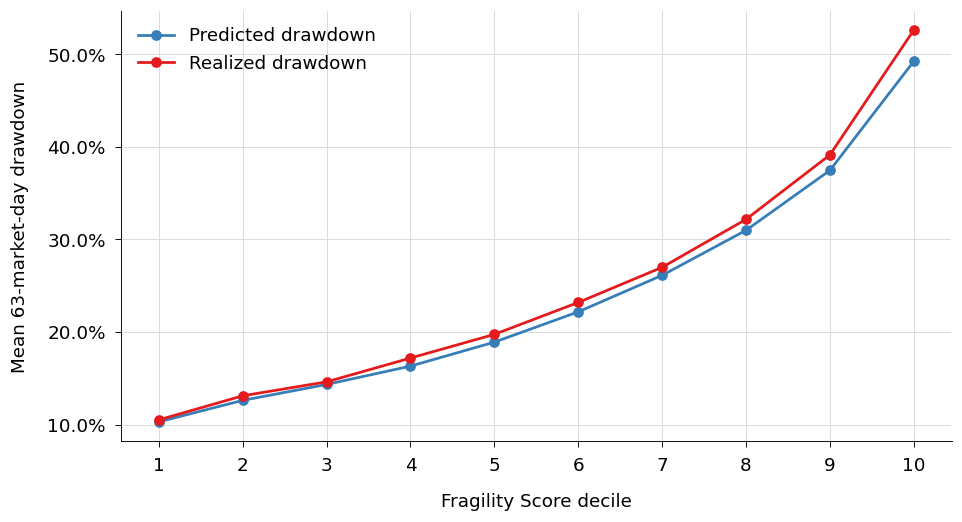

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    decile_summary["fragility_decile"],
    decile_summary["predicted_drawdown"],
    marker="o",
    label="Predicted drawdown",
)
ax.plot(
    decile_summary["fragility_decile"],
    decile_summary["realized_drawdown"],
    marker="o",
    label="Realized drawdown",
)
ax.set(
    xlabel="Fragility Score decile",
    ylabel="Mean 63-market-day drawdown",
    xticks=range(1, 11),
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "05_01_predicted_vs_realized_by_decile.pdf")
plt.show()

In [5]:
display(
    correlations.assign(
        report_period=correlations["report_period"].dt.strftime("%Y-%m-%d")
    ).style.format(
        {
            "stocks": "{:,.0f}",
            "stock_spearman": "{:.3f}",
            "decile_spearman": "{:.3f}",
            "top_minus_bottom_mean_drawdown": "{:.2%}",
        }
    )
)

print(f"Mean stock-level Spearman: {correlations['stock_spearman'].mean():.3f}")
print(f"Mean decile-level Spearman: {correlations['decile_spearman'].mean():.3f}")
print(
    "Mean top-minus-bottom drawdown spread: "
    f"{correlations['top_minus_bottom_mean_drawdown'].mean():.2%}"
)

,report_period,information_date,stocks,stock_spearman,decile_spearman,top_minus_bottom_mean_drawdown
0,2024-03-31,2024-05-15 00:00:00,"4,005",0.803,1.000,46.94%
1,2024-06-30,2024-08-14 00:00:00,"3,946",0.765,1.000,41.78%
2,2024-09-30,2024-11-14 00:00:00,"3,869",0.730,1.000,41.19%
3,2024-12-31,2025-02-14 00:00:00,"3,819",0.729,1.000,43.81%
4,2025-03-31,2025-05-15 00:00:00,"3,767",0.724,1.000,37.70%
5,2025-06-30,2025-08-14 00:00:00,"3,733",0.719,1.000,39.75%
6,2025-09-30,2025-11-14 00:00:00,"3,706",0.747,1.000,46.89%
7,2025-12-31,2026-02-17 00:00:00,"3,666",0.695,1.000,38.53%


Mean stock-level Spearman: 0.739
Mean decile-level Spearman: 1.000
Mean top-minus-bottom drawdown spread: 42.07%


## 3. Supporting stock outcomes

Downside volatility and worst-five-day loss are supporting risk outcomes. Cumulative return is shown only to describe the stocks assigned to each score decile.

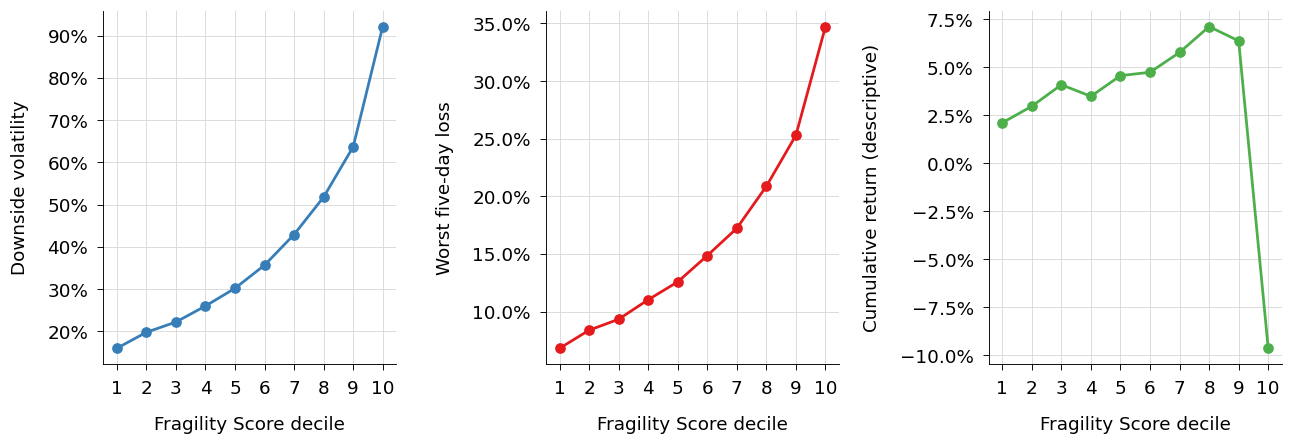

In [6]:
measures = [
    ("downside_volatility", "Downside volatility"),
    ("worst_five_day_loss", "Worst five-day loss"),
    ("cumulative_return", "Cumulative return (descriptive)"),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.3))

for index, (ax, (column, title)) in enumerate(zip(axes, measures)):
    ax.plot(
        decile_summary["fragility_decile"],
        decile_summary[column],
        marker="o",
        color=COLOR_PALETTE[index],
    )
    ax.set(xlabel="Fragility Score decile", ylabel=title, xticks=range(1, 11))
    ax.yaxis.set_major_formatter(PercentFormatter(1))

apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "05_01_supporting_outcomes_by_decile.pdf")
plt.show()

## 4. Portfolio event windows

Each row below summarizes one equal-initial-weight, buy-and-hold portfolio over one 63-market-day event window. Missing daily returns are treated as zero, which is consistent with compounding the observed CRSP returns; after an observed delisting return, any remaining proceeds stay in cash.

In [7]:
portfolio_labels = {
    "all_stocks": "All stocks",
    "exclude_most_fragile_decile": "Exclude decile 10",
    "least_fragile_decile": "Decile 1",
    "most_fragile_decile": "Decile 10",
}
portfolio_summary = (
    portfolios.groupby("portfolio", as_index=False)
    .agg(
        quarters=("report_period", "size"),
        mean_maximum_drawdown=("maximum_drawdown", "mean"),
        median_maximum_drawdown=("maximum_drawdown", "median"),
        mean_downside_volatility=("downside_volatility", "mean"),
        mean_worst_five_day_loss=("worst_five_day_loss", "mean"),
        mean_cumulative_return=("cumulative_return", "mean"),
    )
)
portfolio_summary["portfolio"] = portfolio_summary["portfolio"].map(
    portfolio_labels
)
portfolio_summary["order"] = portfolio_summary["portfolio"].map(
    {"All stocks": 1, "Exclude decile 10": 2, "Decile 1": 3, "Decile 10": 4}
)
portfolio_summary = portfolio_summary.sort_values("order").drop(columns="order")

display(
    portfolio_summary.style.format(
        {
            "quarters": "{:,.0f}",
            "mean_maximum_drawdown": "{:.2%}",
            "median_maximum_drawdown": "{:.2%}",
            "mean_downside_volatility": "{:.2%}",
            "mean_worst_five_day_loss": "{:.2%}",
            "mean_cumulative_return": "{:.2%}",
        }
    )
)

,portfolio,quarters,mean_maximum_drawdown,median_maximum_drawdown,mean_downside_volatility,mean_worst_five_day_loss,mean_cumulative_return
0,All stocks,8,9.59%,7.11%,13.55%,6.28%,3.16%
1,Exclude decile 10,8,8.57%,6.85%,12.68%,5.74%,4.59%
2,Decile 1,8,4.75%,3.50%,6.95%,3.24%,2.12%
3,Decile 10,8,25.29%,23.32%,27.57%,13.80%,-9.64%


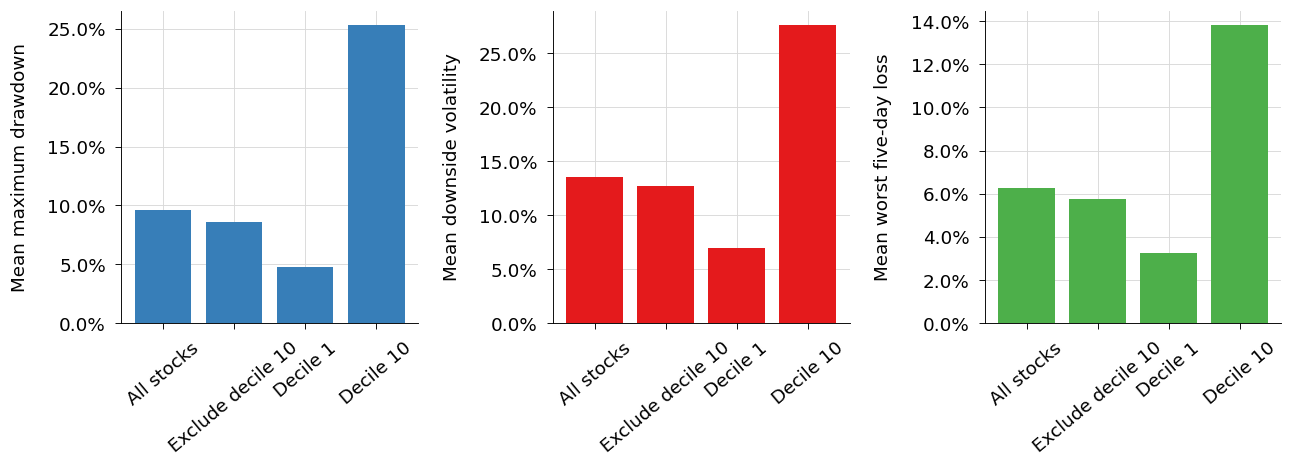

In [8]:
plot_measures = [
    ("mean_maximum_drawdown", "Maximum drawdown"),
    ("mean_downside_volatility", "Downside volatility"),
    ("mean_worst_five_day_loss", "Worst five-day loss"),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))

for index, (ax, (column, title)) in enumerate(zip(axes, plot_measures)):
    ax.bar(
        portfolio_summary["portfolio"],
        portfolio_summary[column],
        color=COLOR_PALETTE[index],
    )
    ax.set_ylabel(f'Mean {title.lower()}')
    ax.tick_params(axis="x", rotation=40)
    ax.yaxis.set_major_formatter(PercentFormatter(1))

apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "05_01_portfolio_risk_by_group.pdf")
plt.show()

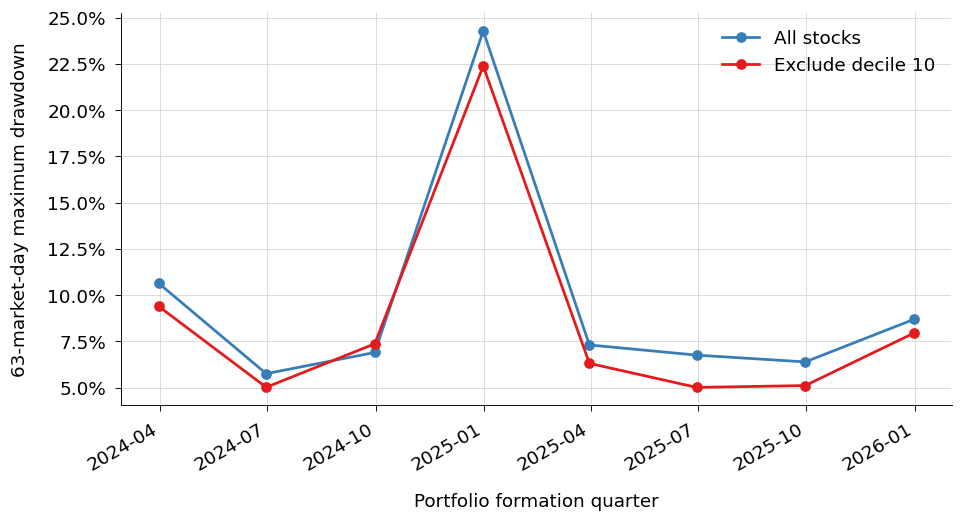

In [9]:
maximum_drawdown = portfolios.pivot(
    index="report_period",
    columns="portfolio",
    values="maximum_drawdown",
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    maximum_drawdown.index,
    maximum_drawdown["all_stocks"],
    marker="o",
    label="All stocks",
)
ax.plot(
    maximum_drawdown.index,
    maximum_drawdown["exclude_most_fragile_decile"],
    marker="o",
    label="Exclude decile 10",
)
ax.set(
    xlabel="Portfolio formation quarter",
    ylabel="63-market-day maximum drawdown",
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
fig.autofmt_xdate()
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "05_01_risk_overlay_by_quarter.pdf")
plt.show()

In [10]:
portfolio_wide = portfolios.pivot(
    index="report_period",
    columns="portfolio",
    values=[
        "maximum_drawdown",
        "downside_volatility",
        "worst_five_day_loss",
        "cumulative_return",
    ],
)
comparison = pd.DataFrame(index=portfolio_wide.index)

for measure in [
    "maximum_drawdown",
    "downside_volatility",
    "worst_five_day_loss",
]:
    comparison[f"{measure}_reduction"] = (
        portfolio_wide[(measure, "all_stocks")]
        - portfolio_wide[(measure, "exclude_most_fragile_decile")]
    )

comparison["cumulative_return_difference"] = (
    portfolio_wide[("cumulative_return", "exclude_most_fragile_decile")]
    - portfolio_wide[("cumulative_return", "all_stocks")]
)
display(comparison.style.format("{:.2%}"))

for measure, label in [
    ("maximum_drawdown", "maximum drawdown"),
    ("downside_volatility", "downside volatility"),
    ("worst_five_day_loss", "worst five-day loss"),
]:
    reduction = comparison[f"{measure}_reduction"]
    print(
        f"{label.capitalize()}: mean reduction {reduction.mean():.2%}; "
        f"improved in {(reduction > 0).sum()}/{len(reduction)} quarters"
    )

print(
    "Cumulative return difference (descriptive): "
    f"{comparison['cumulative_return_difference'].mean():.2%}"
)

,maximum_drawdown_reduction,downside_volatility_reduction,worst_five_day_loss_reduction,cumulative_return_difference
report_period,,,,
2024-03-31 00:00:00,1.25%,0.73%,0.44%,2.64%
2024-06-30 00:00:00,0.74%,0.47%,0.15%,1.81%
2024-09-30 00:00:00,-0.47%,0.43%,0.45%,0.05%
2024-12-31 00:00:00,1.90%,0.56%,-0.03%,2.32%
2025-03-31 00:00:00,0.99%,1.02%,1.01%,-0.80%
2025-06-30 00:00:00,1.75%,1.45%,0.76%,0.92%
2025-09-30 00:00:00,1.28%,1.59%,0.88%,3.80%
2025-12-31 00:00:00,0.74%,0.73%,0.71%,0.67%


Maximum drawdown: mean reduction 1.02%; improved in 7/8 quarters
Downside volatility: mean reduction 0.87%; improved in 8/8 quarters
Worst five-day loss: mean reduction 0.55%; improved in 7/8 quarters
Cumulative return difference (descriptive): 1.42%


## 5. Interpretation

The fixed-test evidence supports the economic interpretation of the Fragility Score. Mean realized drawdown rises monotonically across all ten deciles in every test quarter. The mean stock-level quarterly Spearman correlation is 0.738, and the average realized-drawdown difference between deciles 10 and 1 is 41.79 percentage points.

The fixed top-decile exclusion also improves the primary downside-risk comparison. Relative to the complete equal-weighted universe, it lowers average portfolio maximum drawdown from 9.59% to 8.56%, an absolute reduction of 1.03 percentage points, and improves maximum drawdown in seven of eight event windows. It lowers downside volatility in all eight windows and worst-five-day loss in seven. Its higher average cumulative return is descriptive and is not interpreted as evidence of alpha.

The result is economically meaningful but deliberately limited: it covers eight quarterly event windows, uses equal initial weights, is gross of trading costs, and is not a continuous investment backtest. It therefore supports the Fragility Score as a downside-risk screening signal, not as a standalone return-generating strategy.